In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import tree
import seaborn as sns
import joblib
import ipywidgets as widgets

from catboost import CatBoostClassifier
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.tree import plot_tree

In [2]:
# To display multiple outputs from the same cell use the following codes
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

# Change the width of the current notebook
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

In [3]:
# Importing dataset and putting it in a variable
filename = 'DissertationCompletedDataset.csv'
df = pd.read_csv(filename)
print("Dataset shape: ", df.shape)
print("Sample data of dataset:")
df.head()

Dataset shape:  (1000, 257)
Sample data of dataset:


,PropertyAddress,Postcode,UPRN,FullName,SaleRole,SellDate,CompanyNumber,DirectorName,CountryOfIncorp,Section1,...,FittingsReplaced,OtherFittings,KeysAndCodes,Section14,ConsentsCopies,ConsentsAttached&ToFollow,ConsentsNotAvailable,FurtherInformationDetail,FurtherInformationDocuments,Section15
0,Address1,KQ92 7IL,905768477555,John 1,Trustee(s),18/05/2024,NaN,NaN,NaN,Valid,...,Yes,No,Yes,Follow-up Check,", To follow, ,",& Consents to follow,NaN,NaN,Not applicable,Follow-up Check
1,Address2,G33 2VP,36212248853,John 2,Trustee(s),07/05/2024,YL127717,Jane 2,United Kingdom,Valid,...,No,No,No,Follow-up Check,"Attached, , Not applicable, Not available",Consents attached &,Consents not available,Filler details,Attached,Valid
2,Address3,UH62 8SN,730787419561,John 3,Executor(s)/Administrator(s),01/08/2024,60055102,Jane 3,United Kingdom,Valid,...,Yes,Yes,No,Follow-up Check,", To follow, ,",& Consents to follow,NaN,NaN,Attached,Follow-up Check
3,Address4,HZ99 1WM,953302399372,John 4,Trustee(s),30/08/2024,73184849,Jane 4,United Kingdom,Valid,...,No,Yes,No,Follow-up Check,", To follow, ,",& Consents to follow,NaN,Filler details,To follow,Follow-up Check
4,Address5,UP37 3EQ,714783754024,John 5,Executor(s)/Administrator(s),28/12/2025,36432962,Jane 5,United Kingdom,Valid,...,Yes,Yes,Yes,Valid,"Attached, To follow, Not applicable,",Consents attached & Consents to follow,NaN,NaN,Not applicable,Follow-up Check


In [4]:
# Checking the default data type
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Columns: 257 entries, PropertyAddress to Section15
dtypes: float64(2), int64(1), object(254)
memory usage: 2.0+ MB


In [5]:
df.dtypes

PropertyAddress                object
Postcode                       object
UPRN                            int64
FullName                       object
SaleRole                       object
                                ...  
ConsentsAttached&ToFollow      object
ConsentsNotAvailable           object
FurtherInformationDetail       object
FurtherInformationDocuments    object
Section15                      object
Length: 257, dtype: object

In [6]:
# store columns with specific data type
integer_columns = df.select_dtypes(include=['int64']).columns
float_columns = df.select_dtypes(include=['float64']).columns
object_columns = df.select_dtypes(include=['object']).columns

# display columns
print('\nint64 columns:\n',integer_columns)
print('\nfloat64 columns:\n',float_columns)
print('\nobject columns:\n',object_columns)


int64 columns:
 Index(['UPRN'], dtype='object')

float64 columns:
 Index(['InstallYear', 'MPRN'], dtype='object')

object columns:
 Index(['PropertyAddress', 'Postcode', 'FullName', 'SaleRole', 'SellDate',
       'CompanyNumber', 'DirectorName', 'CountryOfIncorp', 'Section1',
       'LeftBoundary',
       ...
       'FittingsReplaced', 'OtherFittings', 'KeysAndCodes', 'Section14',
       'ConsentsCopies', 'ConsentsAttached&ToFollow', 'ConsentsNotAvailable',
       'FurtherInformationDetail', 'FurtherInformationDocuments', 'Section15'],
      dtype='object', length=254)


In [7]:
# Turning all columns into strings once more
for column in df.columns:
    if df[column].dtype == 'float64':
        df[column] = df[column].astype(str)
    elif df[column].dtype == 'int64':
        df[column] = df[column].astype(str)

In [8]:
# Double-checking the new data types of the columns now
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Columns: 257 entries, PropertyAddress to Section15
dtypes: object(257)
memory usage: 2.0+ MB


In [9]:
# Decide whether to replace all of NaN with empty string. Test out the decision tree for both options first and move on from there.
df.fillna('Empty', inplace=True)

# Decision Tree Section 2

In [10]:
df_section2 = df.iloc[:, 10:23]

In [11]:
df_section2.head()

,LeftBoundary,RightBoundary,RearBoundary,FrontBoundary,IrregularBoundary,BoundaryChanged,ChangeDetail,OverUnderHang,OverUnderDetail,PartyWall,PartyWallDetail,PartyWallNotice,Section2
0,Shared,Neighbour,Seller,Not Known,To follow,No,Empty,Not known,Empty,Yes,Filler details,To follow,Follow-up Check
1,Not Known,Neighbour,Neighbour,Shared,Plan attached,Yes,Filler details,Yes,Filler details,Yes,Filler details,Attached,Follow-up Check
2,Not Known,Neighbour,Seller,Seller,Filler description,Yes,Filler details,No,Empty,No,Empty,Empty,Follow-up Check
3,Neighbour,Seller,Not Known,Neighbour,Filler description,Yes,Filler details,No,Empty,Yes,Filler details,To follow,Follow-up Check
4,Seller,Shared,Shared,Seller,To follow,Yes,Filler details,Yes,Filler details,Yes,Filler details,To follow,Follow-up Check


In [12]:
# input_variables = ['LeftBoundary', "RightBoundary", "RearBoundary", "FrontBoundary", "IrregularBoundary", "BoundaryChanged", "ChangeDetail", 
                   # "OverUnderHang", "OverUnderDetail", "PartyWall", "PartyWallDetail", "PartyWallNotice"]
# encoded_df_section2 = pd.get_dummies(df_section2, columns = input_variables)

In [13]:
# encoded_df_section2.head()

In [14]:
X = df_section2.iloc[:, 0:-1]
y = df_section2['Section2']

In [15]:
X.head()

,LeftBoundary,RightBoundary,RearBoundary,FrontBoundary,IrregularBoundary,BoundaryChanged,ChangeDetail,OverUnderHang,OverUnderDetail,PartyWall,PartyWallDetail,PartyWallNotice
0,Shared,Neighbour,Seller,Not Known,To follow,No,Empty,Not known,Empty,Yes,Filler details,To follow
1,Not Known,Neighbour,Neighbour,Shared,Plan attached,Yes,Filler details,Yes,Filler details,Yes,Filler details,Attached
2,Not Known,Neighbour,Seller,Seller,Filler description,Yes,Filler details,No,Empty,No,Empty,Empty
3,Neighbour,Seller,Not Known,Neighbour,Filler description,Yes,Filler details,No,Empty,Yes,Filler details,To follow
4,Seller,Shared,Shared,Seller,To follow,Yes,Filler details,Yes,Filler details,Yes,Filler details,To follow


In [16]:
y.head()

0    Follow-up Check
1    Follow-up Check
2    Follow-up Check
3    Follow-up Check
4    Follow-up Check
Name: Section2, dtype: object

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

<Figure size 800x400 with 0 Axes>

<Axes: xlabel='Section2', ylabel='count'>

Text(0.5, 1.0, 'Distribution of Target Classes')

Text(0.5, 0, 'Class')

Text(0, 0.5, 'Count')

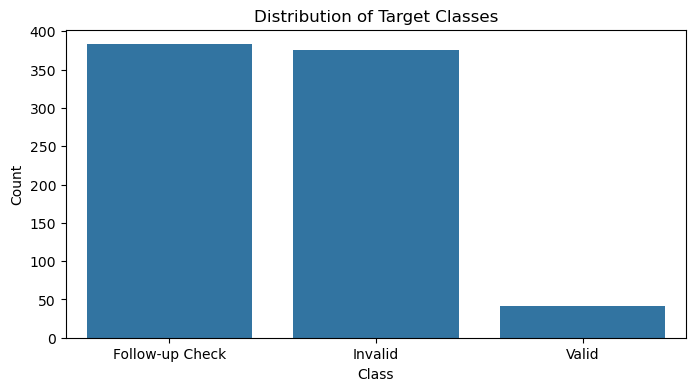

In [18]:
# Create a figure with specified dimensions (8x4)
plt.figure(figsize=(8, 4))

# Generate a countplot to display the distribution of target classes (y_train)
sns.countplot(x=y_train)

# Set the title, x-axis label, and y-axis label for the plot
plt.title('Distribution of Target Classes')
plt.xlabel('Class')
plt.ylabel('Count')

# Display the plot
plt.show()

In [19]:
model = CatBoostClassifier()

In [20]:
input_columns = ['LeftBoundary', "RightBoundary", "RearBoundary", "FrontBoundary", "IrregularBoundary", "BoundaryChanged", "ChangeDetail", "OverUnderHang", 
               "OverUnderDetail", "PartyWall", "PartyWallDetail", "PartyWallNotice"]
model.fit(X_train, y_train, cat_features = input_columns)

Learning rate set to 0.078231
0:	learn: 1.0344455	total: 242ms	remaining: 4m 1s
1:	learn: 0.9756515	total: 281ms	remaining: 2m 20s
2:	learn: 0.9245362	total: 336ms	remaining: 1m 51s
3:	learn: 0.8738533	total: 399ms	remaining: 1m 39s
4:	learn: 0.8325379	total: 445ms	remaining: 1m 28s
5:	learn: 0.7971307	total: 506ms	remaining: 1m 23s
6:	learn: 0.7641295	total: 559ms	remaining: 1m 19s
7:	learn: 0.7393247	total: 619ms	remaining: 1m 16s
8:	learn: 0.7108085	total: 675ms	remaining: 1m 14s
9:	learn: 0.6880508	total: 727ms	remaining: 1m 11s
10:	learn: 0.6614471	total: 794ms	remaining: 1m 11s
11:	learn: 0.6395263	total: 863ms	remaining: 1m 11s
12:	learn: 0.6189084	total: 928ms	remaining: 1m 10s
13:	learn: 0.6001973	total: 1.01s	remaining: 1m 10s
14:	learn: 0.5822305	total: 1.09s	remaining: 1m 11s
15:	learn: 0.5647977	total: 1.16s	remaining: 1m 11s
16:	learn: 0.5527315	total: 1.19s	remaining: 1m 8s
17:	learn: 0.5362161	total: 1.24s	remaining: 1m 7s
18:	learn: 0.5239851	total: 1.3s	remaining: 1m 

CatBoostClassifier()

In [21]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy of CatBoost Classifier: {accuracy:.2f}')

Accuracy of CatBoost Classifier: 0.94


In [22]:
# Classification Report
classification_rep = classification_report(y_test, y_pred)
print("Section 2 Classification Report:\n", classification_rep)

Section 2 Classification Report:
                  precision    recall  f1-score   support

Follow-up Check       0.88      1.00      0.93        86
        Invalid       1.00      0.97      0.98       101
          Valid       1.00      0.31      0.47        13

       accuracy                           0.94       200
      macro avg       0.96      0.76      0.80       200
   weighted avg       0.95      0.94      0.93       200



In [23]:
# Save the trained model
joblib.dump(model, 'catboost_model.pkl')

['catboost_model.pkl']

In [24]:
# Creating a layout and style variable to set the width and height of text
layout = widgets.Layout(width='auto')
style = {'description_width': 'initial'}

In [25]:
# Load the trained model
model = joblib.load('catboost_model.pkl')

# Create input widgets for user input
bound_left = widgets.Text(description="2.1a) Left Boundary Ownership ('Seller', 'Neighbour', 'Shared', 'Not Known'): ", style=style, layout = layout)
bound_right = widgets.Text(description="2.1b) Right Boundary Ownership ('Seller', 'Neighbour', 'Shared', 'Not Known'): ", style=style, layout = layout)
bound_rear = widgets.Text(description="2.1c) Rear Boundary Ownership ('Seller', 'Neighbour', 'Shared', 'Not Known'): ", style=style, layout = layout)
bound_front = widgets.Text(description="2.1d) Front Boundary Ownership ('Seller', 'Neighbour', 'Shared', 'Not Known'): ", style=style, layout = layout)
bound_irregular = widgets.Text(description="2.2) Irregular Boundary Ownership ('Plan attached', 'To follow', 'Filler description': ", style=style, layout = layout)
bound_changed = widgets.Text(description="2.2) Boundary Changed ('Yes', 'No'): ", style=style, layout = layout)
change_detail = widgets.Text(description="2.3) Change Detail ('Empty', 'Filler details'): ", style=style, layout = layout)
over_under_hang = widgets.Text(description="2.4) Any Over or Under Hang('Yes', 'No', 'Not known'): ", style=style, layout = layout)
over_under_detail = widgets.Text(description="2.4) Over or Under Hang Detail ('Empty', 'Filler details'): ", style=style, layout = layout)
party_wall = widgets.Text(description="2.5) Party Wall Act ('Yes', 'No'): ", style=style, layout = layout)
party_wall_detail = widgets.Text(description="2.5) Party Wall Details ('Filler details', 'Empty'): ", style=style, layout = layout)
party_wall_notice = widgets.Text(description="2.5) Party Wall Notice ('Attached', 'To follow'): ", style=style, layout = layout)


In [26]:
# Create a button for making predictions
predict_button = widgets.Button(description="Predict")

# Function to handle prediction on button click


def predict_on_click(b):
    # Collect user inputs and create an input array
    inputs = np.array([[bound_left.value, bound_right.value, bound_rear.value, bound_front.value, bound_irregular.value, bound_changed.value,
                        change_detail.value, over_under_hang.value, over_under_detail.value, party_wall.value, party_wall_detail.value, party_wall_notice.value]])
    # Use the model to predict probabilities
    probabilities = model.predict_proba(inputs)
    class_names = ["Follow-up Check", "Invalid", "Valid"]
    # Determine the predicted class and update the output label
    predicted_class_index = np.argmax(probabilities)
    predicted_class = class_names[predicted_class_index]
    output_label.value = f"Section 2 Evaluation: {predicted_class}"

predict_button.on_click(predict_on_click)

# Display the widgets
display(bound_left, bound_right, bound_rear, bound_front, bound_irregular, bound_changed, change_detail, over_under_hang, over_under_detail, party_wall, party_wall_detail, party_wall_notice, predict_button)

# Create an output label for displaying predictions
output_label = widgets.Label()
display(output_label)

Text(value='', description="2.1a) Left Boundary Ownership ('Seller', 'Neighbour', 'Shared', 'Not Known'): ", l…

Text(value='', description="2.1b) Right Boundary Ownership ('Seller', 'Neighbour', 'Shared', 'Not Known'): ", …

Text(value='', description="2.1c) Rear Boundary Ownership ('Seller', 'Neighbour', 'Shared', 'Not Known'): ", l…

Text(value='', description="2.1d) Front Boundary Ownership ('Seller', 'Neighbour', 'Shared', 'Not Known'): ", …

Text(value='', description="2.2) Irregular Boundary Ownership ('Plan attached', 'To follow', 'Filler descripti…

...

Text(value='', description="2.5) Party Wall Act ('Yes', 'No'): ", layout=Layout(width='auto'), style=TextStyle…

Text(value='', description="2.5) Party Wall Details ('Filler details', 'Empty'): ", layout=Layout(width='auto'…

Text(value='', description="2.5) Party Wall Notice ('Attached', 'To follow'): ", layout=Layout(width='auto'), …

Button(description='Predict', style=ButtonStyle())

Label(value='')

The model can predict accurately. HOWEVER, if the combination of inputs isn't generated in the Excel formula, the result is far more inaccurate.
It's possible to have a combination that would normally result in a "Valid" evaluation by the Section 2 rules instead be "Follow-up Check"

# Decision Tree Section 4

In [27]:
print(df.columns.get_loc('PropertyComm'), df.columns.get_loc('Section4'))

28 34


In [28]:
df_section4 = df.iloc[:, 28:35]

In [29]:
df_section4.head()

,PropertyComm,CommDetail,PropertyPlan,PlanDetail,PropertyAlt,AltDetail,Section4
0,No,Empty,Yes,Filler details,Yes,Filler details,Valid
1,Yes,Filler details,Yes,Filler details,No,Empty,Valid
2,No,Empty,No,Empty,No,Empty,Valid
3,Yes,Filler details,No,Empty,No,Empty,Valid
4,No,Empty,No,Empty,No,Empty,Valid


In [30]:
X2 = df_section4.iloc[:, 0:-1]
y2 = df_section4['Section4']

In [31]:
X2.head()

,PropertyComm,CommDetail,PropertyPlan,PlanDetail,PropertyAlt,AltDetail
0,No,Empty,Yes,Filler details,Yes,Filler details
1,Yes,Filler details,Yes,Filler details,No,Empty
2,No,Empty,No,Empty,No,Empty
3,Yes,Filler details,No,Empty,No,Empty
4,No,Empty,No,Empty,No,Empty


In [32]:
y2.head()

0    Valid
1    Valid
2    Valid
3    Valid
4    Valid
Name: Section4, dtype: object

In [33]:
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

<Figure size 800x400 with 0 Axes>

<Axes: xlabel='Section4', ylabel='count'>

Text(0.5, 1.0, 'Distribution of Target Classes')

Text(0.5, 0, 'Class')

Text(0, 0.5, 'Count')

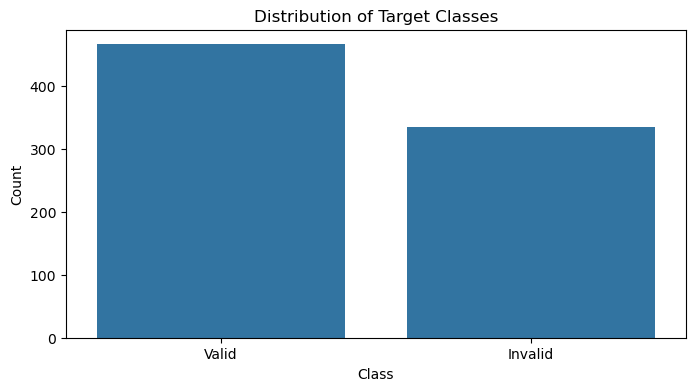

In [34]:
# Create a figure with specified dimensions (8x4)
plt.figure(figsize=(8, 4))

# Generate a countplot to display the distribution of target classes (y_train)
sns.countplot(x=y2_train)

# Set the title, x-axis label, and y-axis label for the plot
plt.title('Distribution of Target Classes')
plt.xlabel('Class')
plt.ylabel('Count')

# Display the plot
plt.show()

In [35]:
model2 = CatBoostClassifier()

In [36]:
input_columns2 = ['PropertyComm', "CommDetail", "PropertyPlan", "PlanDetail", 
               "PropertyAlt", "AltDetail"]
model2.fit(X2_train, y2_train, cat_features = input_columns2)

Learning rate set to 0.009366
0:	learn: 0.6845313	total: 30.2ms	remaining: 30.2s
1:	learn: 0.6746521	total: 69.4ms	remaining: 34.6s
2:	learn: 0.6665638	total: 90.8ms	remaining: 30.2s
3:	learn: 0.6581897	total: 119ms	remaining: 29.7s
4:	learn: 0.6473283	total: 152ms	remaining: 30.2s
5:	learn: 0.6372525	total: 194ms	remaining: 32.1s
6:	learn: 0.6281488	total: 241ms	remaining: 34.2s
7:	learn: 0.6181267	total: 308ms	remaining: 38.2s
8:	learn: 0.6088236	total: 338ms	remaining: 37.2s
9:	learn: 0.5981477	total: 377ms	remaining: 37.3s
10:	learn: 0.5892842	total: 422ms	remaining: 37.9s
11:	learn: 0.5810332	total: 483ms	remaining: 39.8s
12:	learn: 0.5724093	total: 542ms	remaining: 41.2s
13:	learn: 0.5639980	total: 597ms	remaining: 42.1s
14:	learn: 0.5563982	total: 655ms	remaining: 43s
15:	learn: 0.5486236	total: 709ms	remaining: 43.6s
16:	learn: 0.5412714	total: 749ms	remaining: 43.3s
17:	learn: 0.5334991	total: 802ms	remaining: 43.7s
18:	learn: 0.5261273	total: 858ms	remaining: 44.3s
19:	learn:

CatBoostClassifier()

In [37]:
y2_pred = model2.predict(X2_test)

accuracy2 = accuracy_score(y2_test, y2_pred)
print(f'Accuracy of CatBoost Classifier: {accuracy2:.2f}')

Accuracy of CatBoost Classifier: 1.00


In [38]:
# Classification Report
classification_rep2 = classification_report(y2_test, y2_pred)
print("Section 4 Classification Report:\n", classification_rep2)

Section 4 Classification Report:
               precision    recall  f1-score   support

     Invalid       1.00      1.00      1.00        93
       Valid       1.00      1.00      1.00       107

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [39]:
# Save the trained model
joblib.dump(model2, 'catboost_model2.pkl')

['catboost_model2.pkl']

In [40]:
# Load the trained model
model2 = joblib.load('catboost_model2.pkl')

# Create input widgets for user input
prop_comm = widgets.Text(description="4.1) Property Communication ('Yes', 'No', 'Empty'): ", style=style, layout = layout)
comm_detail = widgets.Text(description="4.1) Communication Detail ('Filler details', 'Empty'): ", style=style, layout = layout)
prop_plan = widgets.Text(description="4.2) Property Plan ('Yes', 'No', 'Empty'): ", style=style, layout = layout)
plan_detail = widgets.Text(description="4.2) Plan Detail ('Filler details', 'Empty'): ", style=style, layout = layout)
prop_alt = widgets.Text(description="4.3) Property Alteration ('Yes', 'No', 'Empty'): ", style=style, layout = layout)
alt_detail = widgets.Text(description="4.3) Alteration Detail ('Filler details', 'Empty'): ", style=style, layout = layout)

In [41]:
# Create a button for making predictions
predict_button2 = widgets.Button(description="Predict")

# Function to handle prediction on button click
def predict_on_click2(b):
    # Collect user inputs and create an input array
    inputs = np.array([[prop_comm.value, comm_detail.value, prop_plan.value, plan_detail.value, prop_alt.value, alt_detail.value]])
    # Use the model to predict probabilities
    probabilities = model2.predict_proba(inputs)
    class_names = ["Invalid", "Valid"]
    # Determine the predicted class and update the output label
    predicted_class_index = np.argmax(probabilities)
    predicted_class = class_names[predicted_class_index]
    output_label2.value = f"Section 4 Evaluation: {predicted_class}"

predict_button2.on_click(predict_on_click2)

# Display the widgets
display(prop_comm, comm_detail, prop_plan, plan_detail, prop_alt, alt_detail, predict_button2)

# Create an output label for displaying predictions
output_label2 = widgets.Label()
display(output_label2)

Text(value='', description="4.1) Property Communication ('Yes', 'No', 'Empty'): ", layout=Layout(width='auto')…

Text(value='', description="4.1) Communication Detail ('Filler details', 'Empty'): ", layout=Layout(width='aut…

Text(value='', description="4.2) Property Plan ('Yes', 'No', 'Empty'): ", layout=Layout(width='auto'), style=T…

Text(value='', description="4.2) Plan Detail ('Filler details', 'Empty'): ", layout=Layout(width='auto'), styl…

Text(value='', description="4.3) Property Alteration ('Yes', 'No', 'Empty'): ", layout=Layout(width='auto'), s…

Text(value='', description="4.3) Alteration Detail ('Filler details', 'Empty'): ", layout=Layout(width='auto')…

Button(description='Predict', style=ButtonStyle())

Label(value='')

Unlike Section 2, Section 4 has less questions and no multiple choice question with more than 3 choices back-to-back like 2.1 so there's far less chance of an answer combination that doesn't exists in the dataset that this model can't predict correctly. 
Also, being a more binary classifier makes it far harder for a misclassifcation, unlike Section 2 with 3 classifications

# Decision Tree Section 8 Flood

In [42]:
print(df.columns.get_loc('PropertyFlood'), df.columns.get_loc('Section8Flood'))

113 123


In [43]:
df_section8flood = df.iloc[:, 113:124]

In [44]:
df_section8flood.head()

,PropertyFlood,GroundWater,SewerFlood,SurfaceWater,CoastalFlooding,RiverFlooding,OtherFlood,FloodDetail,FloodDefense,DefenseDetail,Section8Flood
0,No,Empty,Empty,Empty,Empty,Empty,Empty,Empty,No,Empty,Valid
1,Yes,Yes,No,No,No,No,Yes,Filler details,No,Empty,Valid
2,No,Empty,Empty,Empty,Empty,Empty,Empty,Empty,Not known,Empty,Follow-up Check
3,Yes,Yes,No,Yes,No,No,Yes,Filler details,No,Empty,Valid
4,Yes,Yes,No,No,No,Yes,Yes,Filler details,Not known,Empty,Follow-up Check


In [45]:
X3 = df_section8flood.iloc[:, 0:-1]
y3 = df_section8flood['Section8Flood']

In [46]:
X3.head()

,PropertyFlood,GroundWater,SewerFlood,SurfaceWater,CoastalFlooding,RiverFlooding,OtherFlood,FloodDetail,FloodDefense,DefenseDetail
0,No,Empty,Empty,Empty,Empty,Empty,Empty,Empty,No,Empty
1,Yes,Yes,No,No,No,No,Yes,Filler details,No,Empty
2,No,Empty,Empty,Empty,Empty,Empty,Empty,Empty,Not known,Empty
3,Yes,Yes,No,Yes,No,No,Yes,Filler details,No,Empty
4,Yes,Yes,No,No,No,Yes,Yes,Filler details,Not known,Empty


In [47]:
X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, test_size=0.2, random_state=42)

<Figure size 800x400 with 0 Axes>

<Axes: xlabel='Section8Flood', ylabel='count'>

Text(0.5, 1.0, 'Distribution of Target Classes')

Text(0.5, 0, 'Class')

Text(0, 0.5, 'Count')

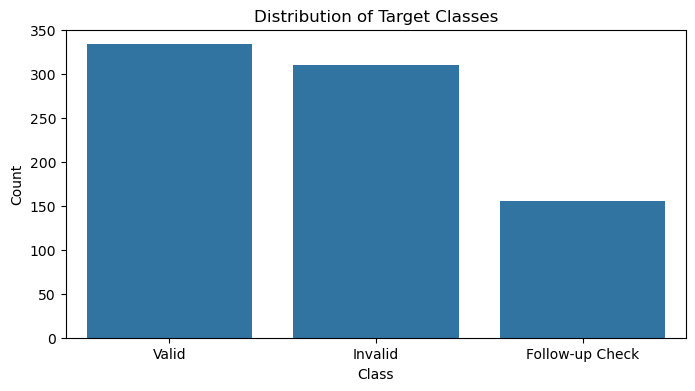

In [48]:
# Create a figure with specified dimensions (8x4)
plt.figure(figsize=(8, 4))

# Generate a countplot to display the distribution of target classes (y_train)
sns.countplot(x=y3_train)

# Set the title, x-axis label, and y-axis label for the plot
plt.title('Distribution of Target Classes')
plt.xlabel('Class')
plt.ylabel('Count')

# Display the plot
plt.show()

In [49]:
model3 = CatBoostClassifier()

In [50]:
input_columns3 = ['PropertyFlood', "GroundWater", "SewerFlood", "SurfaceWater", 
               "CoastalFlooding", "RiverFlooding", "OtherFlood", "FloodDetail", "FloodDefense", "DefenseDetail"]
model3.fit(X3_train, y3_train, cat_features = input_columns3)

Learning rate set to 0.078231
0:	learn: 1.0183846	total: 52.2ms	remaining: 52.1s
1:	learn: 0.9458460	total: 101ms	remaining: 50.6s
2:	learn: 0.8719857	total: 170ms	remaining: 56.5s
3:	learn: 0.8079205	total: 250ms	remaining: 1m 2s
4:	learn: 0.7536520	total: 305ms	remaining: 1m
5:	learn: 0.7142394	total: 339ms	remaining: 56.1s
6:	learn: 0.6725865	total: 389ms	remaining: 55.2s
7:	learn: 0.6333591	total: 442ms	remaining: 54.8s
8:	learn: 0.6001805	total: 496ms	remaining: 54.6s
9:	learn: 0.5815030	total: 550ms	remaining: 54.5s
10:	learn: 0.5531782	total: 606ms	remaining: 54.5s
11:	learn: 0.5234825	total: 669ms	remaining: 55.1s
12:	learn: 0.4994422	total: 748ms	remaining: 56.8s
13:	learn: 0.4756233	total: 842ms	remaining: 59.3s
14:	learn: 0.4532005	total: 939ms	remaining: 1m 1s
15:	learn: 0.4344250	total: 1.04s	remaining: 1m 4s
16:	learn: 0.4184590	total: 1.1s	remaining: 1m 3s
17:	learn: 0.3971558	total: 1.16s	remaining: 1m 3s
18:	learn: 0.3815039	total: 1.21s	remaining: 1m 2s
19:	learn: 0.3

CatBoostClassifier()

In [51]:
y3_pred = model3.predict(X3_test)

accuracy3 = accuracy_score(y3_test, y3_pred)
print(f'Accuracy of CatBoost Classifier: {accuracy3:.2f}')

Accuracy of CatBoost Classifier: 0.98


In [52]:
# Classification Report
classification_rep3 = classification_report(y3_test, y3_pred)
print("Section 8 Flood Classification Report:\n", classification_rep3)

Section 8 Flood Classification Report:
                  precision    recall  f1-score   support

Follow-up Check       1.00      1.00      1.00        31
        Invalid       1.00      0.96      0.98        85
          Valid       0.97      1.00      0.98        84

       accuracy                           0.98       200
      macro avg       0.99      0.99      0.99       200
   weighted avg       0.99      0.98      0.98       200



In [53]:
# Save the trained model
joblib.dump(model3, 'catboost_model3.pkl')

['catboost_model3.pkl']

In [54]:
# Load the trained model
model3 = joblib.load('catboost_model3.pkl')

# Create input widgets for user input
prop_flood = widgets.Text(description="8.1) Property Flood ('Yes', 'No', 'Empty'): ", style=style, layout = layout)
ground_water = widgets.Text(description="8.1) Ground Water Flood ('Yes', 'No', 'Empty'): ", style=style, layout = layout)
sewer_flood = widgets.Text(description="8.1) Sewer Flood ('Yes', 'No', 'Empty'): ", style=style, layout = layout)
surface_water = widgets.Text(description="8.1) Surface Water Flood ('Yes', 'No', 'Empty'): ", style=style, layout = layout)
coastal_flood = widgets.Text(description="8.1) Coastal Flood ('Yes', 'No', 'Empty'): ", style=style, layout = layout)
river_flood = widgets.Text(description="8.1) River Flood ('Yes', 'No', 'Empty'): ", style=style, layout = layout)
other_flood = widgets.Text(description="8.1) Other Flood ('Yes', 'No', 'Empty'): ", style=style, layout = layout)
flood_detail = widgets.Text(description="8.1) Flood Detail ('Filler details', 'Empty'): ", style=style, layout = layout)
flood_defense = widgets.Text(description="8.2) Flood Defense ('Yes', 'No', 'Not known', 'Empty'): ", style=style, layout = layout)
defense_detail = widgets.Text(description="8.2) Defense Detail ('Filler details', 'Empty'): ", style=style, layout = layout)

In [55]:
# Create a button for making predictions
predict_button3 = widgets.Button(description="Predict")

# Function to handle prediction on button click
def predict_on_click3(b):
    # Collect user inputs and create an input array
    inputs = np.array([[prop_flood.value, ground_water.value, sewer_flood.value, surface_water.value, coastal_flood.value, river_flood.value, 
                       other_flood.value, flood_detail.value, flood_defense.value, defense_detail.value]])
    # Use the model to predict probabilities
    probabilities = model3.predict_proba(inputs)
    class_names = ["Follow-up Check", "Invalid", "Valid"]
    # Determine the predicted class and update the output label
    predicted_class_index = np.argmax(probabilities)
    predicted_class = class_names[predicted_class_index]
    output_label3.value = f"Section 8 Flood Evaluation: {predicted_class}"

predict_button3.on_click(predict_on_click3)

# Display the widgets
display(prop_flood, ground_water, sewer_flood, surface_water, coastal_flood, river_flood, other_flood, flood_detail, flood_defense, defense_detail, predict_button3)

# Create an output label for displaying predictions
output_label3 = widgets.Label()
display(output_label3)

Text(value='', description="8.1) Property Flood ('Yes', 'No', 'Empty'): ", layout=Layout(width='auto'), style=…

Text(value='', description="8.1) Ground Water Flood ('Yes', 'No', 'Empty'): ", layout=Layout(width='auto'), st…

Text(value='', description="8.1) Sewer Flood ('Yes', 'No', 'Empty'): ", layout=Layout(width='auto'), style=Tex…

Text(value='', description="8.1) Surface Water Flood ('Yes', 'No', 'Empty'): ", layout=Layout(width='auto'), s…

Text(value='', description="8.1) Coastal Flood ('Yes', 'No', 'Empty'): ", layout=Layout(width='auto'), style=T…

...

Text(value='', description="8.1) Flood Detail ('Filler details', 'Empty'): ", layout=Layout(width='auto'), sty…

Text(value='', description="8.2) Flood Defense ('Yes', 'No', 'Not known', 'Empty'): ", layout=Layout(width='au…

Text(value='', description="8.2) Defense Detail ('Filler details', 'Empty'): ", layout=Layout(width='auto'), s…

Button(description='Predict', style=ButtonStyle())

Label(value='')

Section 8 Flood has many multiple choices as a follow-up condition to a Yes or No question. Unlike Section 2, since the choices are limited to just two choices that are polar opposite of one another, there's far less chance of a mismatch in evaluation through weird combination of values.

# Section 11 Heating Decision Tree

In [56]:
print(df.columns.get_loc('PropertyHeating'), df.columns.get_loc('Section11Heat'))

171 182


In [57]:
df_section11heat = df.iloc[:, 171:183]

In [58]:
df_section11heat.head()

,PropertyHeating,OtherHeatingDetail,HeatingInstall,BoilerInstall,HeatingReplace,HeatingAltCert,InspectionCopy,HeatingBoilerWork,HeatingBoilerYear,ServiceReportCopy,MultipleHeatingSystem,Section11Heat
0,"Mains gas,,Heat pumps,,Electricity,,,Other",Filler description,Not known,Not known,Not known,To follow,Attached,Not known,Not known,To follow,Attached,Follow-up Check
1,",Oil,,Liquid gas,,,Woodburning/multi-fuel stov...",Filler description,08/02/2026,Not known,No,Empty,Attached,No,Not known,To follow,Attached,Follow-up Check
2,"Mains gas,,Heat pumps,Liquid gas,Electricity,U...",Filler description,09/24/2026,09/09/2025,No,Attached,Attached,Not known,2002,To follow,To follow,Follow-up Check
3,"Mains gas,,Heat pumps,,Electricity,Underfloor,...",Filler description,10/05/2025,Not known,No,Empty,Attached,No,1982,To follow,To follow,Follow-up Check
4,",,,Liquid gas,Electricity,,Woodburning/multi-f...",Filler description,Not known,Not known,No,To follow,Empty,Yes,Not known,To follow,To follow,Follow-up Check


In [59]:
X4 = df_section11heat.iloc[:, 0:-1]
y4 = df_section11heat['Section11Heat']

In [60]:
X4.head()

,PropertyHeating,OtherHeatingDetail,HeatingInstall,BoilerInstall,HeatingReplace,HeatingAltCert,InspectionCopy,HeatingBoilerWork,HeatingBoilerYear,ServiceReportCopy,MultipleHeatingSystem
0,"Mains gas,,Heat pumps,,Electricity,,,Other",Filler description,Not known,Not known,Not known,To follow,Attached,Not known,Not known,To follow,Attached
1,",Oil,,Liquid gas,,,Woodburning/multi-fuel stov...",Filler description,08/02/2026,Not known,No,Empty,Attached,No,Not known,To follow,Attached
2,"Mains gas,,Heat pumps,Liquid gas,Electricity,U...",Filler description,09/24/2026,09/09/2025,No,Attached,Attached,Not known,2002,To follow,To follow
3,"Mains gas,,Heat pumps,,Electricity,Underfloor,...",Filler description,10/05/2025,Not known,No,Empty,Attached,No,1982,To follow,To follow
4,",,,Liquid gas,Electricity,,Woodburning/multi-f...",Filler description,Not known,Not known,No,To follow,Empty,Yes,Not known,To follow,To follow


In [61]:
X4_train, X4_test, y4_train, y4_test = train_test_split(X4, y4, test_size=0.2, random_state=42)

<Figure size 800x400 with 0 Axes>

<Axes: xlabel='Section11Heat', ylabel='count'>

Text(0.5, 1.0, 'Distribution of Target Classes')

Text(0.5, 0, 'Class')

Text(0, 0.5, 'Count')

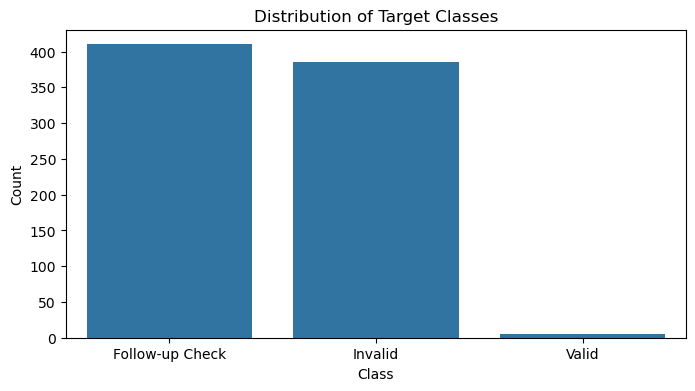

In [62]:
# Create a figure with specified dimensions (8x4)
plt.figure(figsize=(8, 4))

# Generate a countplot to display the distribution of target classes (y_train)
sns.countplot(x=y4_train)

# Set the title, x-axis label, and y-axis label for the plot
plt.title('Distribution of Target Classes')
plt.xlabel('Class')
plt.ylabel('Count')

# Display the plot
plt.show()

In [63]:
model4 = CatBoostClassifier()

In [64]:
input_columns4 = ['PropertyHeating', "OtherHeatingDetail", "HeatingInstall", "BoilerInstall", 
               "HeatingReplace", "HeatingAltCert", "InspectionCopy", "HeatingBoilerWork", "HeatingBoilerYear", "ServiceReportCopy", "MultipleHeatingSystem"]
model4.fit(X4_train, y4_train, cat_features = input_columns4)

Learning rate set to 0.078231
0:	learn: 1.0153291	total: 55.4ms	remaining: 55.4s
1:	learn: 0.9478178	total: 89.9ms	remaining: 44.9s
2:	learn: 0.8876964	total: 157ms	remaining: 52.1s
3:	learn: 0.8352484	total: 223ms	remaining: 55.6s
4:	learn: 0.7875283	total: 273ms	remaining: 54.3s
5:	learn: 0.7493223	total: 341ms	remaining: 56.5s
6:	learn: 0.7146778	total: 411ms	remaining: 58.2s
7:	learn: 0.6773406	total: 457ms	remaining: 56.7s
8:	learn: 0.6438457	total: 528ms	remaining: 58.2s
9:	learn: 0.6143456	total: 599ms	remaining: 59.4s
10:	learn: 0.5881780	total: 670ms	remaining: 1m
11:	learn: 0.5647702	total: 736ms	remaining: 1m
12:	learn: 0.5376744	total: 774ms	remaining: 58.8s
13:	learn: 0.5115549	total: 848ms	remaining: 59.7s
14:	learn: 0.4893347	total: 912ms	remaining: 59.9s
15:	learn: 0.4697339	total: 985ms	remaining: 1m
16:	learn: 0.4504847	total: 1.06s	remaining: 1m 1s
17:	learn: 0.4283788	total: 1.2s	remaining: 1m 5s
18:	learn: 0.4098872	total: 1.28s	remaining: 1m 6s
19:	learn: 0.392346

CatBoostClassifier()

In [65]:
y4_pred = model4.predict(X4_test)

accuracy4 = accuracy_score(y4_test, y4_pred)
print(f'Accuracy of CatBoost Classifier: {accuracy4:.2f}')

Accuracy of CatBoost Classifier: 0.94


In [66]:
# Classification Report
classification_rep4 = classification_report(y4_test, y4_pred)
print("Section 11 Heating Classification Report:\n", classification_rep4)

Section 11 Heating Classification Report:
                  precision    recall  f1-score   support

Follow-up Check       0.91      0.99      0.95        99
        Invalid       0.99      0.91      0.95       100
          Valid       0.00      0.00      0.00         1

       accuracy                           0.94       200
      macro avg       0.63      0.63      0.63       200
   weighted avg       0.94      0.94      0.94       200



C:\Users\atpso\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\atpso\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\atpso\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [67]:
# Save the trained model
joblib.dump(model4, 'catboost_model4.pkl')

['catboost_model4.pkl']

In [68]:
# Load the trained model
model4 = joblib.load('catboost_model4.pkl')

# Create input widgets for user input
prop_heating = widgets.Text(description="11.4) Property Heating ('Mains gas', 'Oil', 'Heat pumps', 'Liquid gas', 'Electricity', 'Underfloor', 'Woodburning / multi-fuel stove', 'Other'): ", style=style, layout = layout)
other_detail = widgets.Text(description="11.4) Other Detail ('Filler description', 'Empty'): ", style=style, layout = layout)
heating_install = widgets.Text(description="11.4a) Heating Install Date ('mm/dd/yyyy', 'Not known', 'Empty'): ", style=style, layout = layout)
boiler_install = widgets.Text(description="11.4b) Boiler Install Date('mm/dd/yyyy', 'Not known', 'Empty'): ", style=style, layout = layout)
heating_replace = widgets.Text(description="11.4c) Heating Replacement ('Yes', 'No', 'Not known', 'Empty'): ", style=style, layout = layout)
heating_alt_cert = widgets.Text(description="11.4d) Heating Alteration Cert ('Yes', 'No', 'Not known', 'Empty'): ", style=style, layout = layout)
inspection_copy = widgets.Text(description="11.4e) Inspection Copy ('Attached', 'To follow', 'None', 'Empty'): ", style=style, layout = layout)
heat_boiler_work = widgets.Text(description="11.4f) Heat/Boiler Working ('Yes', 'No', 'Not known', 'Empty'): ", style=style, layout = layout)
heat_boiler_year = widgets.Text(description="11.4g) Heat/Boiler Year ('yyyy', 'Not known', 'Empty'): ", style=style, layout = layout)
service_report_copy = widgets.Text(description="11.4g) Service Report Copy ('Attached', 'To follow', 'Empty'): ", style=style, layout = layout)
mult_heating_sys = widgets.Text(description="11.4h) Multiple heating system ('Attached', 'To follow', 'Empty'): ", style=style, layout = layout)

In [69]:
# Create a button for making predictions
predict_button4 = widgets.Button(description="Predict")

# Function to handle prediction on button click
def predict_on_click4(b):
    # Collect user inputs and create an input array
    inputs = np.array([[prop_heating.value, other_detail.value, heating_install.value, boiler_install.value, heating_replace.value, heating_alt_cert.value, 
                       inspection_copy.value, heat_boiler_work.value, heat_boiler_year.value, service_report_copy.value, mult_heating_sys.value]])
    # Use the model to predict probabilities
    probabilities = model4.predict_proba(inputs)
    class_names = ["Follow-up Check", "Invalid", "Valid"]
    # Determine the predicted class and update the output label
    predicted_class_index = np.argmax(probabilities)
    predicted_class = class_names[predicted_class_index]
    output_label4.value = f"Section 11 Heat Evaluation: {predicted_class}"

predict_button4.on_click(predict_on_click4)

# Display the widgets
display(prop_heating, other_detail, heating_install, boiler_install, heating_replace, heating_alt_cert, inspection_copy, heat_boiler_work, heat_boiler_year, service_report_copy, mult_heating_sys, predict_button4)

# Create an output label for displaying predictions
output_label4 = widgets.Label()
display(output_label4)

Text(value='', description="11.4) Property Heating ('Mains gas', 'Oil', 'Heat pumps', 'Liquid gas', 'Electrici…

Text(value='', description="11.4) Other Detail ('Filler description', 'Empty'): ", layout=Layout(width='auto')…

Text(value='', description="11.4a) Heating Install Date ('mm/dd/yyyy', 'Not known', 'Empty'): ", layout=Layout…

Text(value='', description="11.4b) Boiler Install Date('mm/dd/yyyy', 'Not known', 'Empty'): ", layout=Layout(w…

Text(value='', description="11.4c) Heating Replacement ('Yes', 'No', 'Not known', 'Empty'): ", layout=Layout(w…

...

Text(value='', description="11.4g) Heat/Boiler Year ('yyyy', 'Not known', 'Empty'): ", layout=Layout(width='au…

Text(value='', description="11.4g) Service Report Copy ('Attached', 'To follow', 'Empty'): ", layout=Layout(wi…

Text(value='', description="11.4h) Multiple heating system ('Attached', 'To follow', 'Empty'): ", layout=Layou…

Button(description='Predict', style=ButtonStyle())

Label(value='')

Due to the difficulty of translating the tick-all-that-applies question's answers into values and various range of answers within question asking for dates, the accuracy of this evaluation tool is suspect. If the tick-all-that-applies and date questions were simplified into whether or not they were answered (i.e. if they tick anything at all and if they gave a date at all), then it would have been more like the previous section's evaluation and be much easier to evaluate accurately. Also, this section leaves little room for a "Valid" evaluation, making it hard to train the model to recognize it.

# Section 12 Electricity Decision Tree

In [70]:
print(df.columns.get_loc('MainElec'), df.columns.get_loc('Section12Elec'))

201 205


In [71]:
df_section12elec = df.iloc[:, 201:206]

In [72]:
df_section12elec.head()

,MainElec,ElecProvider,ElecMeter,MPAN,Section12Elec
0,Yes,Filler name,Filler location,S-07-686-849-48-06742021-743,Valid
1,Yes,Filler name,Filler location,S-04-993-619-48-18649869-366,Valid
2,No,Empty,Empty,Empty,Valid
3,No,Empty,Empty,Empty,Valid
4,No,Empty,Empty,Empty,Valid


In [73]:
# Making a new column to simplify all of MPAN's unique values
df_section12elec['MPAN_ans'] = ''

In [74]:
df_section12elec.head()

,MainElec,ElecProvider,ElecMeter,MPAN,Section12Elec,MPAN_ans
0,Yes,Filler name,Filler location,S-07-686-849-48-06742021-743,Valid,
1,Yes,Filler name,Filler location,S-04-993-619-48-18649869-366,Valid,
2,No,Empty,Empty,Empty,Valid,
3,No,Empty,Empty,Empty,Valid,
4,No,Empty,Empty,Empty,Valid,


In [75]:
for i, x in enumerate(df_section12elec['MPAN_ans']):
    # if the MPAN section isn't 'empty', it means there is an answer 
    if df_section12elec.loc[i, 'MPAN'] != 'Empty':
        df_section12elec.loc[i, 'MPAN_ans'] = 'Yes'

    else:
        df_section12elec.loc[i, 'MPAN_ans'] = 'No'

In [76]:
df_section12elec.head()

,MainElec,ElecProvider,ElecMeter,MPAN,Section12Elec,MPAN_ans
0,Yes,Filler name,Filler location,S-07-686-849-48-06742021-743,Valid,Yes
1,Yes,Filler name,Filler location,S-04-993-619-48-18649869-366,Valid,Yes
2,No,Empty,Empty,Empty,Valid,No
3,No,Empty,Empty,Empty,Valid,No
4,No,Empty,Empty,Empty,Valid,No


In [77]:
X5 = df_section12elec[['MainElec', 'ElecProvider', 'ElecMeter', 'MPAN_ans']]
y5 = df_section12elec['Section12Elec']

In [78]:
X5_train, X5_test, y5_train, y5_test = train_test_split(X5, y5, test_size=0.2, random_state=42)

<Figure size 800x400 with 0 Axes>

<Axes: xlabel='Section12Elec', ylabel='count'>

Text(0.5, 1.0, 'Distribution of Target Classes')

Text(0.5, 0, 'Class')

Text(0, 0.5, 'Count')

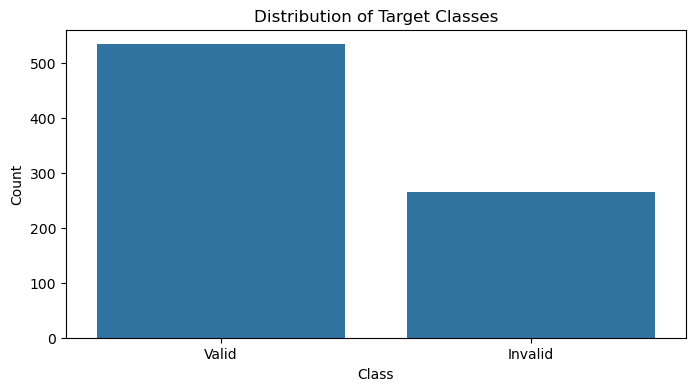

In [79]:
# Create a figure with specified dimensions (8x4)
plt.figure(figsize=(8, 4))

# Generate a countplot to display the distribution of target classes (y_train)
sns.countplot(x=y5_train)

# Set the title, x-axis label, and y-axis label for the plot
plt.title('Distribution of Target Classes')
plt.xlabel('Class')
plt.ylabel('Count')

# Display the plot
plt.show()

In [80]:
model5 = CatBoostClassifier()

In [81]:
input_columns5 = ['MainElec', 'ElecProvider', "ElecMeter", "MPAN_ans"]
model5.fit(X5_train, y5_train, cat_features = input_columns5)

Learning rate set to 0.009366
0:	learn: 0.6739164	total: 96.5ms	remaining: 1m 36s
1:	learn: 0.6490002	total: 187ms	remaining: 1m 33s
2:	learn: 0.6295715	total: 284ms	remaining: 1m 34s
3:	learn: 0.6056100	total: 352ms	remaining: 1m 27s
4:	learn: 0.5882135	total: 403ms	remaining: 1m 20s
5:	learn: 0.5674151	total: 447ms	remaining: 1m 14s
6:	learn: 0.5526356	total: 485ms	remaining: 1m 8s
7:	learn: 0.5380937	total: 524ms	remaining: 1m 5s
8:	learn: 0.5209927	total: 560ms	remaining: 1m 1s
9:	learn: 0.5022198	total: 598ms	remaining: 59.2s
10:	learn: 0.4832244	total: 634ms	remaining: 57s
11:	learn: 0.4680070	total: 671ms	remaining: 55.3s
12:	learn: 0.4510403	total: 742ms	remaining: 56.3s
13:	learn: 0.4340274	total: 817ms	remaining: 57.5s
14:	learn: 0.4225930	total: 886ms	remaining: 58.2s
15:	learn: 0.4181105	total: 904ms	remaining: 55.6s
16:	learn: 0.4098034	total: 936ms	remaining: 54.1s
17:	learn: 0.3972868	total: 984ms	remaining: 53.7s
18:	learn: 0.3821766	total: 1.04s	remaining: 53.9s
19:	le

CatBoostClassifier()

In [82]:
y5_pred = model5.predict(X5_test)

accuracy5 = accuracy_score(y5_test, y5_pred)
print(f'Accuracy of CatBoost Classifier: {accuracy5:.2f}')

Accuracy of CatBoost Classifier: 1.00


In [83]:
# Classification Report
classification_rep5 = classification_report(y5_test, y5_pred)
print("Section 12 Electricity Classification Report:\n", classification_rep5)

Section 12 Electricity Classification Report:
               precision    recall  f1-score   support

     Invalid       1.00      1.00      1.00        63
       Valid       1.00      1.00      1.00       137

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [84]:
# Save the trained model
joblib.dump(model5, 'catboost_model5.pkl')

['catboost_model5.pkl']

In [85]:
# Load the trained model
model5 = joblib.load('catboost_model5.pkl')

# Create input widgets for user input
main_elec = widgets.Text(description="Mains Electricity ('Yes', 'No', 'Empty'): ", style=style, layout = layout)
elec_provider = widgets.Text(description="Provider's Name ('Filler name', 'Empty'): ", style=style, layout = layout)
elec_meter = widgets.Text(description="Location of Meter ('Filler location', 'Empty'): ", style=style, layout = layout)
mpan_ans = widgets.Text(description="MPAN Answered ('Yes', 'No'): ", style=style, layout = layout)

In [86]:
# Create a button for making predictions
predict_button5 = widgets.Button(description="Predict")

# Function to handle prediction on button click
def predict_on_click5(b):
    # Collect user inputs and create an input array
    inputs = np.array([[main_elec.value, elec_provider.value, elec_meter.value, mpan_ans.value]])
    # Use the model to predict probabilities
    probabilities = model5.predict_proba(inputs)
    class_names = ["Invalid", "Valid"]
    # Determine the predicted class and update the output label
    predicted_class_index = np.argmax(probabilities)
    predicted_class = class_names[predicted_class_index]
    output_label5.value = f"Section 12 Electricty Evaluation: {predicted_class}"

predict_button5.on_click(predict_on_click5)

# Display the widgets
display(main_elec, elec_provider, elec_meter, mpan_ans, predict_button5)

# Create an output label for displaying predictions
output_label5 = widgets.Label()
display(output_label5)

Text(value='', description="Mains Electricity ('Yes', 'No', 'Empty'): ", layout=Layout(width='auto'), style=Te…

Text(value='', description="Provider's Name ('Filler name', 'Empty'): ", layout=Layout(width='auto'), style=Te…

Text(value='', description="Location of Meter ('Filler location', 'Empty'): ", layout=Layout(width='auto'), st…

Text(value='', description="MPAN Answered ('Yes', 'No'): ", layout=Layout(width='auto'), style=TextStyle(descr…

Button(description='Predict', style=ButtonStyle())

Label(value='')

# Section 5 Alteration Decision Tree

In [87]:
print(df.columns.get_loc('WindowAlt'), df.columns.get_loc('Section5Alt'))

35 57


In [88]:
df_section5alt = df.iloc[:, 35:58]

In [89]:
df_section5alt.head()

,WindowAlt,ExtensionAlt,ConserAlt,LoftAlt,GarageAlt,IntWallAlt,ChimneyAlt,InsulationAlt,OtherAlt,AlterDetail,...,PermAcquire,PermDetail,NonResidentPurpose,NonResidentDetail,NonResidentCopy,PermBreach,BreachDetail,PlanIssue,IssueDetail,Section5Alt
0,No,No,No,No,Yes,No,Yes,No,Yes,Filler details,...,Yes,Empty,Yes,Filler details,To follow,No,Empty,Yes,Filler details,Follow-up Check
1,Yes,Yes,Yes,No,No,No,No,No,No,Filler details,...,Yes,Empty,Yes,Filler details,Attached,Yes,Filler details,No,Empty,Follow-up Check
2,Yes,No,No,No,Yes,Yes,Yes,No,No,Filler details,...,No,Filler explanation,Yes,Filler details,To follow,No,Empty,Yes,Filler details,Follow-up Check
3,Yes,Yes,No,Yes,No,No,Yes,No,Yes,Filler details,...,Yes,Empty,Yes,Filler details,To follow,Yes,Filler details,Yes,Filler details,Follow-up Check
4,Yes,Yes,No,Yes,Yes,No,Yes,Yes,Yes,Filler details,...,Yes,Empty,No,Empty,Empty,No,Empty,Yes,Filler details,Follow-up Check


In [90]:
X6 = df_section5alt.iloc[:, 0:-1]
y6 = df_section5alt['Section5Alt']

In [91]:
X6_train, X6_test, y6_train, y6_test = train_test_split(X6, y6, test_size=0.2, random_state=42)

<Figure size 800x400 with 0 Axes>

<Axes: xlabel='Section5Alt', ylabel='count'>

Text(0.5, 1.0, 'Distribution of Target Classes')

Text(0.5, 0, 'Class')

Text(0, 0.5, 'Count')

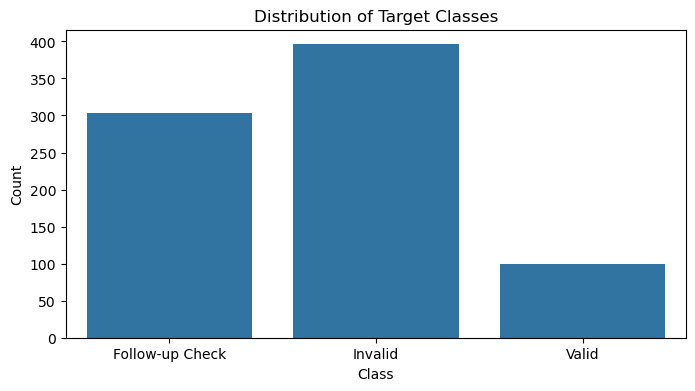

In [92]:
# Create a figure with specified dimensions (8x4)
plt.figure(figsize=(8, 4))

# Generate a countplot to display the distribution of target classes (y_train)
sns.countplot(x=y6_train)

# Set the title, x-axis label, and y-axis label for the plot
plt.title('Distribution of Target Classes')
plt.xlabel('Class')
plt.ylabel('Count')

# Display the plot
plt.show()

In [93]:
df_section5alt_inputs = df_section5alt.iloc[:, 0:-1]

In [94]:
print(list(df_section5alt_inputs))

['WindowAlt', 'ExtensionAlt', 'ConserAlt', 'LoftAlt', 'GarageAlt', 'IntWallAlt', 'ChimneyAlt', 'InsulationAlt', 'OtherAlt', 'AlterDetail', 'AltComplete', 'CompleteDetail', 'PermCopy', 'PermAcquire', 'PermDetail', 'NonResidentPurpose', 'NonResidentDetail', 'NonResidentCopy', 'PermBreach', 'BreachDetail', 'PlanIssue', 'IssueDetail']


In [95]:
model6 = CatBoostClassifier()

In [96]:
input_columns6 = list(df_section5alt_inputs)
model6.fit(X6_train, y6_train, cat_features = input_columns6)

Learning rate set to 0.078231
0:	learn: 1.0185045	total: 86.3ms	remaining: 1m 26s
1:	learn: 0.9444413	total: 159ms	remaining: 1m 19s
2:	learn: 0.8849170	total: 236ms	remaining: 1m 18s
3:	learn: 0.8256642	total: 314ms	remaining: 1m 18s
4:	learn: 0.7720162	total: 385ms	remaining: 1m 16s
5:	learn: 0.7265503	total: 495ms	remaining: 1m 22s
6:	learn: 0.6839718	total: 597ms	remaining: 1m 24s
7:	learn: 0.6499157	total: 675ms	remaining: 1m 23s
8:	learn: 0.6102847	total: 761ms	remaining: 1m 23s
9:	learn: 0.5779166	total: 865ms	remaining: 1m 25s
10:	learn: 0.5464187	total: 969ms	remaining: 1m 27s
11:	learn: 0.5172026	total: 1.06s	remaining: 1m 26s
12:	learn: 0.4912020	total: 1.14s	remaining: 1m 26s
13:	learn: 0.4640178	total: 1.22s	remaining: 1m 26s
14:	learn: 0.4432533	total: 1.31s	remaining: 1m 25s
15:	learn: 0.4202257	total: 1.38s	remaining: 1m 24s
16:	learn: 0.4002636	total: 1.46s	remaining: 1m 24s
17:	learn: 0.3802169	total: 1.54s	remaining: 1m 24s
18:	learn: 0.3620247	total: 1.62s	remaining

CatBoostClassifier()

In [97]:
y6_pred = model6.predict(X6_test)

accuracy6 = accuracy_score(y6_test, y6_pred)
print(f'Accuracy of CatBoost Classifier: {accuracy6:.2f}')

Accuracy of CatBoost Classifier: 1.00


In [98]:
# Classification Report
classification_rep6 = classification_report(y6_test, y6_pred)
print("Section 5 Alteration Classification Report:\n", classification_rep6)

Section 5 Alteration Classification Report:
                  precision    recall  f1-score   support

Follow-up Check       1.00      1.00      1.00        83
        Invalid       1.00      1.00      1.00       104
          Valid       1.00      1.00      1.00        13

       accuracy                           1.00       200
      macro avg       1.00      1.00      1.00       200
   weighted avg       1.00      1.00      1.00       200



In [99]:
# Save the trained model
joblib.dump(model6, 'catboost_model6.pkl')

['catboost_model6.pkl']

In [100]:
# Load the trained model
model6 = joblib.load('catboost_model6.pkl')

# Create input widgets for user input
window_alt = widgets.Text(description="5.1a) Window Alteration ('Yes', 'No', 'Empty'): ", style=style, layout = layout)
extension_alt = widgets.Text(description="5.1b) Ext. Alt. ('Yes', 'No', 'Empty'): ", style=style, layout = layout)
conser_alt = widgets.Text(description="5.1c) Conser. Alt. ('Yes', 'No', 'Empty'): ", style=style, layout = layout)
loft_alt = widgets.Text(description="5.1d) Loft Alt. ('Yes', 'No', 'Empty'): ", style=style, layout = layout)
garage_alt = widgets.Text(description="5.1e) Garage Alt. ('Yes', 'No', 'Empty'): ", style=style, layout = layout)
int_wall_alt = widgets.Text(description="5.1f) Int. Wall Alt. ('Yes', 'No', 'Empty'): ", style=style, layout = layout)
chimney_alt = widgets.Text(description="5.1g) Chimney Alt. ('Yes', 'No', 'Empty'): ", style=style, layout = layout)
insulation_alt = widgets.Text(description="5.1h) Insulation Alt. ('Yes', 'No', 'Empty'): ", style=style, layout = layout)
other_alt = widgets.Text(description="5.1i) Other Alt. ('Yes', 'No', 'Empty'): ", style=style, layout = layout)
alter_detail = widgets.Text(description="5.2a) Alt. Detail ('Filler details', 'Empty'): ", style=style, layout = layout)
alt_complete = widgets.Text(description="5.2b) Alt. Complete ('Yes', 'No', 'Empty'): ", style=style, layout = layout)
com_detail = widgets.Text(description="5.2b) Complete Detail ('Filler details', 'Empty'): ", style=style, layout = layout)
perm_copy = widgets.Text(description="5.2c) Perm. Copy ('Attached', 'To follow', 'Not available'): ", style=style, layout = layout)
perm_acquire = widgets.Text(description="5.2di) Perm. Acquire ('Yes', 'No', 'Empty'): ", style=style, layout = layout)
perm_detail = widgets.Text(description="5.2dii) Perm. Detail ('Filler explanation', 'Empty'): ", style=style, layout = layout)
non_resident_purpose = widgets.Text(description="5.3) Non-resident Purpose ('Yes', 'No', 'Empty'): ", style=style, layout = layout)
non_resident_detail = widgets.Text(description="5.3) Non-resident Detail ('Filler details', 'Empty'): ", style=style, layout = layout)
non_resident_copy = widgets.Text(description="5.3) Non-resident Copy ('Attached', 'To follow', 'Empty'): ", style=style, layout = layout)
perm_breach = widgets.Text(description="5.4) Perm. Breach (Yes, No, Empty): ", style=style, layout = layout)
breach_detail = widgets.Text(description= "5.4) Breach Detail (Filler details, Empty): ", style=style, layout = layout)
plan_issue = widgets.Text(description="5.5) Planning Issue (Yes, No, Empty): ", style=style, layout = layout)
issue_detail = widgets.Text(description="5.5) Issue Detail (Filler details, Empty): ", style=style, layout = layout)

In [101]:
# Create a button for making predictions
predict_button6 = widgets.Button(description="Predict")

# Function to handle prediction on button click
def predict_on_click6(b):
    # Collect user inputs and create an input array
    inputs = np.array([[window_alt.value, extension_alt.value, conser_alt.value, loft_alt.value, garage_alt.value, int_wall_alt.value, chimney_alt.value,
                       insulation_alt.value, other_alt.value, alter_detail.value, alt_complete.value, com_detail.value, perm_copy.value, perm_acquire.value,
                       perm_detail.value, non_resident_purpose.value, non_resident_detail.value, non_resident_copy.value, perm_breach.value, breach_detail.value, plan_issue.value, issue_detail.value]])
    # Use the model to predict probabilities
    probabilities = model6.predict_proba(inputs)
    class_names = ["Follow-up Check", "Invalid", "Valid"]
    # Determine the predicted class and update the output label
    predicted_class_index = np.argmax(probabilities)
    predicted_class = class_names[predicted_class_index]
    output_label5.value = f"Section 5 Alt Evaluation: {predicted_class}"

predict_button6.on_click(predict_on_click6)

# Display the widgets
display(window_alt, extension_alt, conser_alt, loft_alt, garage_alt, int_wall_alt, chimney_alt, insulation_alt, other_alt, alter_detail, alt_complete,
       com_detail, perm_copy, perm_acquire, perm_detail, non_resident_purpose, non_resident_detail, non_resident_copy, perm_breach, breach_detail, plan_issue, issue_detail, predict_button6)

# Create an output label for displaying predictions
output_label6 = widgets.Label()
display(output_label6)

Text(value='', description="5.1a) Window Alteration ('Yes', 'No', 'Empty'): ", layout=Layout(width='auto'), st…

Text(value='', description="5.1b) Ext. Alt. ('Yes', 'No', 'Empty'): ", layout=Layout(width='auto'), style=Text…

Text(value='', description="5.1c) Conser. Alt. ('Yes', 'No', 'Empty'): ", layout=Layout(width='auto'), style=T…

Text(value='', description="5.1d) Loft Alt. ('Yes', 'No', 'Empty'): ", layout=Layout(width='auto'), style=Text…

Text(value='', description="5.1e) Garage Alt. ('Yes', 'No', 'Empty'): ", layout=Layout(width='auto'), style=Te…

...

Text(value='', description='5.4) Breach Detail (Filler details, Empty): ', layout=Layout(width='auto'), style=…

Text(value='', description='5.5) Planning Issue (Yes, No, Empty): ', layout=Layout(width='auto'), style=TextSt…

Text(value='', description='5.5) Issue Detail (Filler details, Empty): ', layout=Layout(width='auto'), style=T…

Button(description='Predict', style=ButtonStyle())

Label(value='')